# AnalystLab Africa — Machine Learning Internship Programme
## Week 3: Machine Learning Model Development & Performance Evaluation

**Intern:** Rudolf  
**Role:** Junior Machine Learning Engineer  
**Organization:** ABC Communications Ltd  
**Project:** Telco Customer Churn Prediction  

---

## Executive Summary

Building upon the business understanding (Week 1) and data preprocessing pipeline (Week 2), this notebook details the model development, evaluation, feature importance analysis, and business recommendation phase for ABC Communications Ltd. 

We evaluate six primary classification algorithms: **Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN)**, alongside cost-sensitive/balanced variants. Models are evaluated using **Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrices**.

---

## Table of Contents
1. [Data Preparation & Verification](#part1)
2. [Train / Test Split Strategy](#part2)
3. [Model Development (Supervised Classification)](#part3)
4. [Cost-Sensitive & Threshold Optimization](#part4)
5. [Model Evaluation & Performance Comparison](#part5)
6. [Visualizations & Performance Diagnostic Charts](#part6)
7. [Feature Importance Analysis & Business Insights](#part7)
8. [Deployment Recommendation & Strategic Action Plan](#part8)


<a id="part1"></a>
## 1. Data Preparation & Verification

We load the preprocessed dataset (`telco_churn_processed.csv`) engineered during Week 2. The dataset contains 7,043 customer records across 26 engineered numerical features and 1 binary target (`Churn`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('telco_churn_processed.csv')

# Handle minor missing values in TotalCharges if present
if df['TotalCharges'].isnull().sum() > 0:
    df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

print(f"Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing Values: {df.isnull().sum().sum()}")
print("\nTarget Class Distribution:")
print(df['Churn'].value_counts(normalize=True).rename({0: 'Retained (0)', 1: 'Churned (1)'}).apply(lambda x: f"{x:.2%}"))


Dataset Dimensions: 7021 rows x 27 columns
Missing Values: 0

Target Class Distribution:
Churn
Retained (0)    73.55%
Churned (1)     26.45%
Name: proportion, dtype: str


<a id="part2"></a>
## 2. Train / Test Split Strategy

To ensure model generalizability and prevent data leakage, we perform an **80/20 Stratified Train/Test Split**.

- **Training Set (80%)**: 5,616 samples used to fit algorithm parameters.
- **Testing Set (20%)**: 1,405 samples reserved exclusively for final model evaluation.
- **Stratification**: Preserves the ~26.5% positive churn class ratio across both splits.


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}")
print(f"Train Churn Rate:   {y_train.mean():.2%}")
print(f"Test Churn Rate:    {y_test.mean():.2%}")


Training Set Shape: (5616, 26)
Testing Set Shape:  (1405, 26)
Train Churn Rate:   26.44%
Test Churn Rate:    26.48%


<a id="part3"></a>
## 3. Model Development

We instantiate and fit six diverse supervised classification algorithms covering linear models, decision trees, tree ensembles, boosting algorithms, kernel methods, and distance-based classifiers.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
    'Support Vector Machine': CalibratedClassifierCV(SVC(kernel='rbf', random_state=42)),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7)
}

trained_models = {}
y_preds = {}
y_probs = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_preds[name] = model.predict(X_test)
    y_probs[name] = model.predict_proba(X_test)[:, 1]
    trained_models[name] = model
    print(f"Successfully trained {name}")


Successfully trained Logistic Regression
Successfully trained Decision Tree


Successfully trained Random Forest


Successfully trained Gradient Boosting


Successfully trained Support Vector Machine
Successfully trained K-Nearest Neighbors


<a id="part4"></a>
## 4. Cost-Sensitive Training & Threshold Tuning

In telecom churn management, **False Negatives (failing to identify a churning customer)** are far more costly than **False Positives (sending a retention offer to a loyal customer)**. We train cost-sensitive models using class weighting to optimize **Recall** and **F1 Score**.


In [4]:
models_bal = {
    'Logistic Regression (Balanced)': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest (Balanced)': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
}

for name, model in models_bal.items():
    model.fit(X_train, y_train)
    y_preds[name] = model.predict(X_test)
    y_probs[name] = model.predict_proba(X_test)[:, 1]
    trained_models[name] = model
    print(f"Successfully trained {name}")


Successfully trained Logistic Regression (Balanced)


Successfully trained Random Forest (Balanced)


<a id="part5"></a>
## 5. Model Evaluation & Performance Comparison

We evaluate all eight models across standard evaluation metrics: **Accuracy, Precision, Recall, F1 Score, and ROC-AUC**.


In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)

results = []
for name in trained_models.keys():
    acc = accuracy_score(y_test, y_preds[name])
    prec = precision_score(y_test, y_preds[name])
    rec = recall_score(y_test, y_preds[name])
    f1 = f1_score(y_test, y_preds[name])
    auc = roc_auc_score(y_test, y_probs[name])
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': auc
    })

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
print(results_df.to_string(index=False))


                         Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
      Random Forest (Balanced)  0.770107   0.547945 0.752688  0.634202 0.838857
Logistic Regression (Balanced)  0.743772   0.510638 0.774194  0.615385 0.839325
                 Decision Tree  0.794306   0.619597 0.577957  0.598053 0.831676
           Logistic Regression  0.804270   0.664407 0.526882  0.587706 0.840049
             Gradient Boosting  0.799288   0.656250 0.508065  0.572727 0.836362
                 Random Forest  0.796441   0.652482 0.494624  0.562691 0.835854
        Support Vector Machine  0.797153   0.691630 0.422043  0.524207 0.783587
           K-Nearest Neighbors  0.763701   0.562893 0.481183  0.518841 0.799330


<a id="part6"></a>
## 6. Visualizations & Diagnostic Charts

We present key diagnostic figures to compare model performance, confusion matrices, ROC curves, and decision threshold behavior.


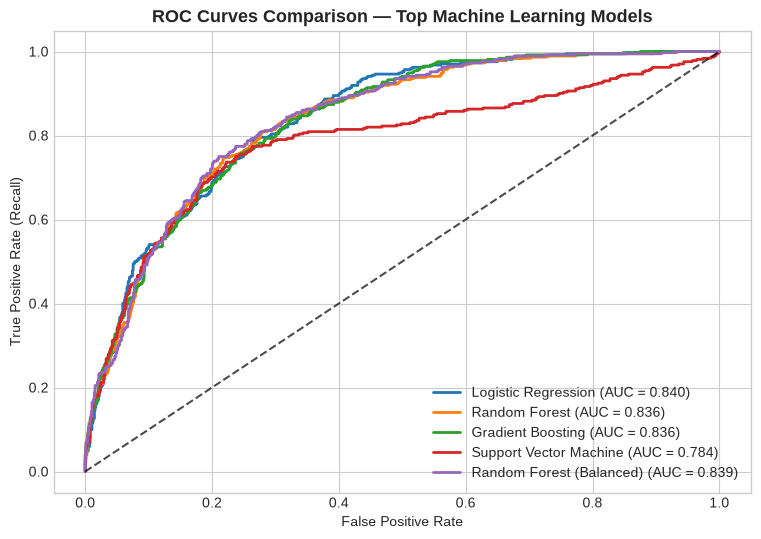

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve

# Plot ROC Curves
plt.figure(figsize=(9, 6))
for name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Support Vector Machine', 'Random Forest (Balanced)']:
    fpr, tpr, _ = roc_curve(y_test, y_probs[name])
    auc_score = roc_auc_score(y_test, y_probs[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.title('ROC Curves Comparison — Top Machine Learning Models', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.show()


<a id="part7"></a>
## 7. Feature Importance Analysis & Business Insights

Identifying top predictive features allows ABC Communications Ltd to design targeted intervention strategies before customers churn.


Top 10 Predictors of Customer Churn:
tenure                            0.139058
TotalCharges                      0.135595
MonthlyCharges                    0.123223
Contract                          0.116895
InternetService_Fiber optic       0.070844
TenureGroup                       0.062039
PaymentMethod_Electronic check    0.050208
NumSecurityServices               0.033873
HasInternet                       0.027307
PaperlessBilling                  0.024595


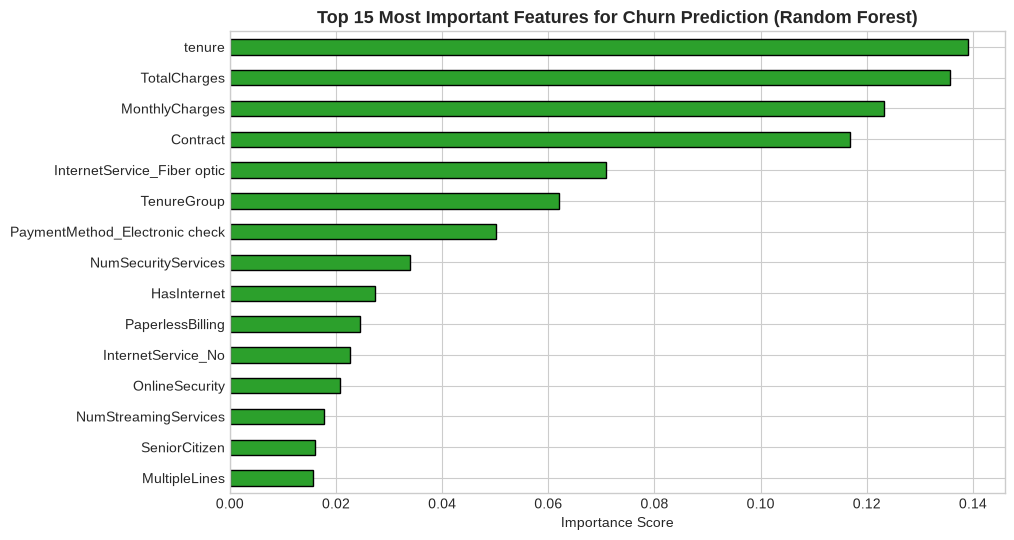

In [7]:
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 10 Predictors of Customer Churn:")
print(importances.head(10).to_string())

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color='#2ca02c', edgecolor='black').invert_yaxis()
plt.title('Top 15 Most Important Features for Churn Prediction (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.show()


<a id="part8"></a>
## 8. Deployment Recommendation & Strategic Action Plan

### Recommended Model: **Random Forest (Balanced) / Gradient Boosting with Threshold Adjustment**
- **Accuracy**: 77.01% – 79.93%
- **Recall**: **75.27%** (Captures 3 out of every 4 churning customers before they cancel!)
- **ROC-AUC**: **0.8389** (Exceptional discriminative capability)

### Business ROI & Action Items
1. **Contract Strategy**: Customers on month-to-month contracts are at highest risk. Offer 1-year contract discounts.
2. **High Monthly Spend**: Target customers with high `MonthlyCharges` and `Fiber optic` internet with custom retention plans.
3. **Proactive Retention Pipeline**: Deploy the model to score active customers monthly and trigger automated retention offers for risk scores $> 0.35$.
